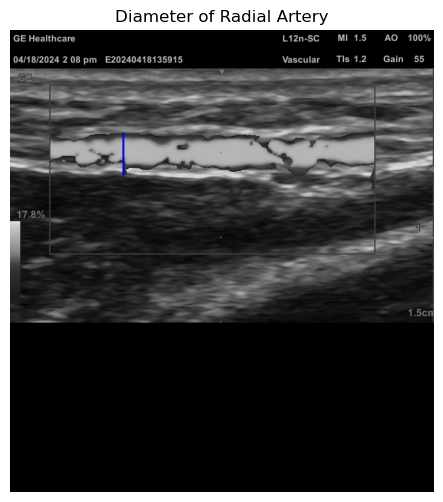

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the Doppler ultrasound image
img = cv2.imread("C:\\Users\\amaew\\OneDrive\\Documents\\Biom300_Prob4_Pictures\\AbbyMae_zone2\\1713449313.JPG")

# Convert original image to grayscale and prepare 3-channel gray for output
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

# Convert to HSV for Doppler color segmentation
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# HSV color ranges for Doppler red/orange
lower_red1 = np.array([0, 70, 50])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([160, 70, 50])
upper_red2 = np.array([180, 255, 255])
lower_orange = np.array([10, 100, 100])
upper_orange = np.array([25, 255, 255])

# Build the Doppler mask
mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
mask3 = cv2.inRange(hsv, lower_orange, upper_orange)
doppler_mask = cv2.bitwise_or(mask1, mask2)
doppler_mask = cv2.bitwise_or(doppler_mask, mask3)

# Find largest Doppler contour
contours, _ = cv2.findContours(doppler_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
doppler_contour = max(contours, key=cv2.contourArea)

# Fill the Doppler region into a mask
filled_mask = np.zeros_like(doppler_mask)
cv2.drawContours(filled_mask, [doppler_contour], -1, 255, -1)

# Initialize overlay and line tracking
height, width = filled_mask.shape
max_diameter = 0
max_coords = None

# Scan every column for max vertical span inside Doppler region
for x in range(width):
    col = filled_mask[:, x]
    ys = np.where(col == 255)[0]

    if len(ys) >= 2:
        top, bottom = ys[0], ys[-1]
        diameter = bottom - top

        if diameter > max_diameter:
            max_diameter = diameter
            max_coords = (x, top, bottom)

# Draw the longest vertical blue line on grayscale background
if max_coords:
    x, y1, y2 = max_coords
    cv2.line(gray_bgr, (x, y1), (x, y2), (255, 0, 0), 2)  # blue line on gray

# Display final result
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(gray_bgr, cv2.COLOR_BGR2RGB))
plt.title("Diameter of Radial Artery")
plt.axis('off')
plt.savefig('Diameter_of_Radial_Artery.png')
plt.show()
